In [1]:
# Loading the datasets and inspecting their structure
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
wuenic_file = r"C:\Users\user\Downloads\wuenic2025rev_web-update.xlsx"
wuenic_master_file = r"C:\Users\user\Downloads\wuenic_input_to_pdf.xlsx"
survey_file = r"C:\Users\user\Downloads\survey-data_wuenic2025rev.xlsx"
hpv_file = r"C:\Users\user\Downloads\hpv2025rev_web-update.xlsx"
wuenic = pd.read_excel(wuenic_file, sheet_name="country")
wuenic_master = pd.read_excel(wuenic_master_file, sheet_name="wuenic_master")
survey = pd.read_excel(
    survey_file,
    sheet_name="survey-data_wuenic2025rev",
    header=1
)

hpv = pd.read_excel(hpv_file, sheet_name="country")

print("WUENIC country dataset:", wuenic.shape)
print("WUENIC master dataset:", wuenic_master.shape)
print("Survey dataset:", survey.shape)
print("HPV dataset:", hpv.shape)
print("\nWUENIC columns:")
print(wuenic.columns.tolist())
print("\nHPV columns:")
print(hpv.columns.tolist())
print("\nSurvey columns:")
print(survey.columns.tolist())

WUENIC country dataset: (58291, 15)
WUENIC master dataset: (47103, 14)
Survey dataset: (51316, 14)
HPV dataset: (3426, 17)

WUENIC columns:
['iso3c', 'country', 'vaccine', 'year', 'target_grp', 'coverage', 'source', 'unicef', 'gavi', 'world_bank', 'world_bank_fcv', 'who', 'who_fcv', 'african_union', 'european_union']

HPV columns:
['iso3c', 'country', 'year', 'vaccine', 'vaccine_code', 'vaccine_name', 'vaccine_description', 'coverage', 'source', 'african_union', 'european_union', 'gavi', 'unicef', 'world_bank', 'world_bank_fcv', 'who', 'who_fcv']

Survey columns:
['ISO3', 'surveyNameEnglish', 'surveyNameProduction', 'collectBegin', 'collectEnd', 'cohortYear', 'vaccine', 'evidence', 'cardsSeen', 'validity', 'ageVaccination', 'ageInterview', 'coverage', 'denominator']


In [2]:
# Cleaning WUENIC data and creating a robust FCV classification

wuenic["year"] = pd.to_numeric(wuenic["year"], errors="coerce")
wuenic["coverage"] = pd.to_numeric(wuenic["coverage"], errors="coerce")

wuenic = wuenic.dropna(
    subset=["iso3c", "country", "year", "vaccine", "coverage"]
).copy()

wuenic["iso3c"] = (
    wuenic["iso3c"]
    .astype(str)
    .str.upper()
    .str.strip()
)

wuenic["country"] = (
    wuenic["country"]
    .astype(str)
    .str.strip()
)

wuenic["vaccine"] = (
    wuenic["vaccine"]
    .astype(str)
    .str.lower()
    .str.strip()
)

wuenic["world_bank_fcv"] = (
    wuenic["world_bank_fcv"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Creating the FCV classification using pandas rather than np.where.
fcv_mapping = {
    "wb_fcv": "FCV",
    "non_wb_fcv": "Non-FCV"
}

wuenic["FCV"] = (
    wuenic["world_bank_fcv"]
    .map(fcv_mapping)
    .astype("string")
)

# Keeping infant target-group observations for the main analysis.
infant_data = wuenic[
    wuenic["target_grp"].astype(str).str.lower().eq("si")
].copy()

print("Total cleaned WUENIC observations:", len(wuenic))
print("Infant target-group observations:", len(infant_data))

print("\nFCV classification:")
print(
    infant_data["FCV"]
    .value_counts(dropna=False)
)

print("\nYear range:")
print(
    infant_data["year"].min(),
    "to",
    infant_data["year"].max()
)

print("\nVaccines available:")
print(
    sorted(infant_data["vaccine"].dropna().unique())
)

print("\nMissing FCV classifications:")
print(
    infant_data["FCV"].isna().sum()
)

Total cleaned WUENIC observations: 58291
Infant target-group observations: 45707

FCV classification:
FCV
Non-FCV    40429
FCV         5278
Name: count, dtype: Int64

Year range:
1980 to 2025

Vaccines available:
['dtp1', 'dtp3', 'hepb3', 'hib3', 'ipv1', 'ipvc', 'mcv1', 'mcv2', 'menga', 'pcvc', 'rcv1', 'rotac', 'yfv']

Missing FCV classifications:
0


In [3]:
# Checking missing values, duplicates, and coverage ranges

quality = pd.DataFrame({
    "missing": infant_data.isna().sum(),
    "missing_percent": infant_data.isna().mean() * 100,
    "unique_values": infant_data.nunique()
})

print("Data quality summary:")
display(quality.sort_values("missing_percent", ascending=False))

duplicate_count = infant_data.duplicated(
    subset=["iso3c", "year", "vaccine", "target_grp"]
).sum()

print("\nDuplicate country-year-vaccine observations:", duplicate_count)

print("\nCoverage summary:")
print(infant_data["coverage"].describe())

invalid_coverage = infant_data[
    (infant_data["coverage"] < 0) |
    (infant_data["coverage"] > 100)
]

print("\nInvalid coverage observations:", len(invalid_coverage))

print("\nDTP3 observations:")
dtp3_check = infant_data[infant_data["vaccine"].eq("dtp3")]
print(dtp3_check.shape)

print("\nDTP3 missing coverage:")
print(dtp3_check["coverage"].isna().sum())

Data quality summary:


,missing,missing_percent,unique_values
european_union,39028,85.387359,1
african_union,33781,73.907717,5
who_fcv,203,0.444133,2
who,203,0.444133,6
iso3c,0,0.000000,195
country,0,0.000000,195
vaccine,0,0.000000,13
year,0,0.000000,46
unicef,0,0.000000,8
source,0,0.000000,1



Duplicate country-year-vaccine observations: 0

Coverage summary:
count    45707.000000
mean        83.257882
std         19.458089
min          0.000000
25%         77.000000
50%         91.000000
75%         97.000000
max         99.000000
Name: coverage, dtype: float64

Invalid coverage observations: 0

DTP3 observations:
(8340, 16)

DTP3 missing coverage:
0


In [4]:
# Creating the primary DTP3 dataset

dtp3 = infant_data[
    infant_data["vaccine"].eq("dtp3")
].copy()

dtp3 = dtp3.dropna(subset=["coverage", "FCV"])

dtp3["year"] = dtp3["year"].astype(int)

print("DTP3 observations:", len(dtp3))
print("Countries represented:", dtp3["iso3c"].nunique())
print("Years represented:", dtp3["year"].min(), "to", dtp3["year"].max())

print("\nCountries by FCV status:")
print(
    dtp3.groupby("FCV")["iso3c"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nDTP3 coverage by FCV status:")
display(
    dtp3.groupby("FCV")["coverage"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

DTP3 observations: 8340
Countries represented: 195
Years represented: 1980 to 2025

Countries by FCV status:
FCV
Non-FCV    171
FCV         24
Name: iso3c, dtype: int64

DTP3 coverage by FCV status:


,count,mean,median,std,min,max
FCV,,,,,,
FCV,1028,60.24,63.0,26.46,1,99
Non-FCV,7312,83.29,91.0,19.13,1,99


In [5]:
# Calculate annual DTP3 coverage and the FCV inequality gap

annual_dtp3 = (
    dtp3
    .groupby(["year", "FCV"])
    .agg(
        mean_coverage=("coverage", "mean"),
        median_coverage=("coverage", "median"),
        countries=("iso3c", "nunique"),
        sd=("coverage", "std")
    )
    .reset_index()
)

annual_dtp3["se"] = (
    annual_dtp3["sd"] /
    np.sqrt(annual_dtp3["countries"])
)

annual_dtp3["lower_95"] = (
    annual_dtp3["mean_coverage"] -
    1.96 * annual_dtp3["se"]
)

annual_dtp3["upper_95"] = (
    annual_dtp3["mean_coverage"] +
    1.96 * annual_dtp3["se"]
)

gap_table = (
    annual_dtp3
    .pivot(index="year", columns="FCV", values="mean_coverage")
)

gap_table["FCV_gap"] = (
    gap_table["Non-FCV"] - gap_table["FCV"]
)

print("Annual DTP3 coverage:")
display(gap_table.round(2))

print("\nLargest observed FCV gaps:")
display(
    gap_table.sort_values("FCV_gap", ascending=False)
    .head(10)
    .round(2)
)

Annual DTP3 coverage:


FCV,FCV,Non-FCV,FCV_gap
year,,,
1980,18.25,51.32,33.07
1981,17.11,53.08,35.96
1982,19.17,55.48,36.31
1983,19.78,56.75,36.97
1984,23.89,58.60,34.71
1985,27.38,62.10,34.72
1986,33.86,67.62,33.77
1987,36.71,71.20,34.49
1988,45.57,74.25,28.68



Largest observed FCV gaps:


FCV,FCV,Non-FCV,FCV_gap
year,,,
1983,19.78,56.75,36.97
1982,19.17,55.48,36.31
1981,17.11,53.08,35.96
1985,27.38,62.10,34.72
1984,23.89,58.60,34.71
1987,36.71,71.20,34.49
1986,33.86,67.62,33.77
1980,18.25,51.32,33.07
1988,45.57,74.25,28.68


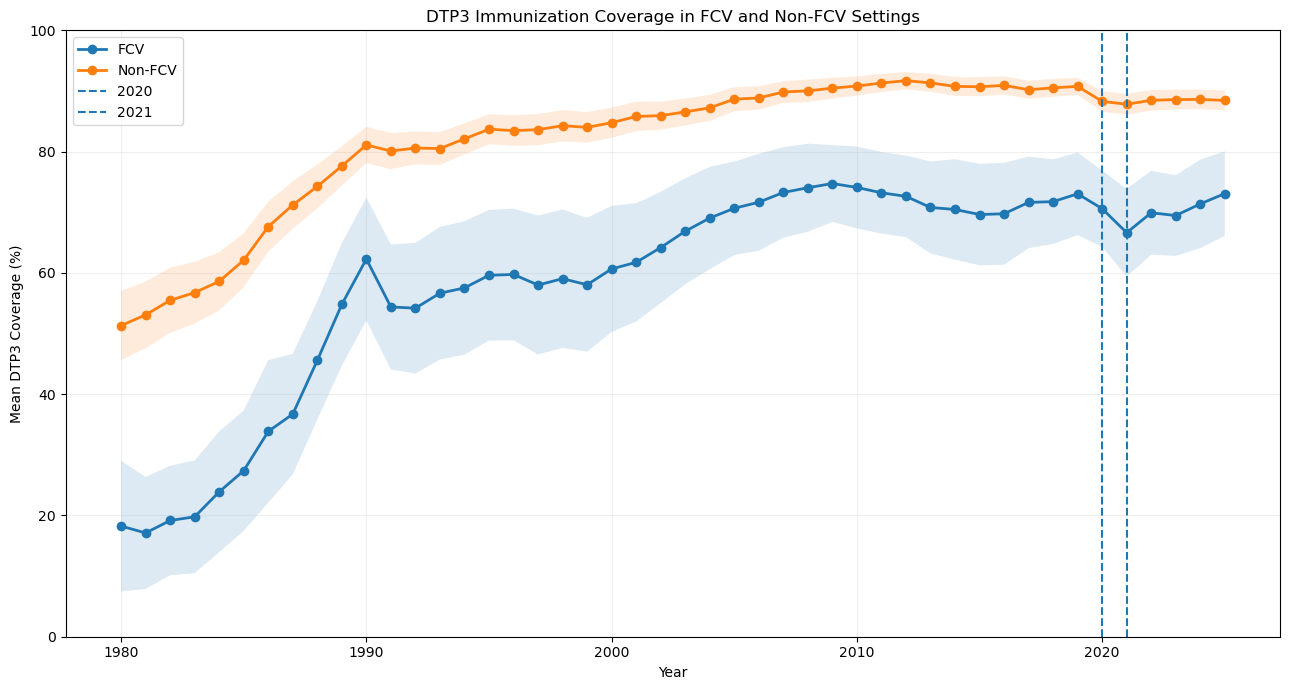

In [6]:
# Plot the long-term DTP3 coverage gap

plt.figure(figsize=(13, 7))

for group in ["FCV", "Non-FCV"]:
    subset = annual_dtp3[annual_dtp3["FCV"].eq(group)].sort_values("year")

    plt.plot(
        subset["year"],
        subset["mean_coverage"],
        marker="o",
        linewidth=2,
        label=group
    )

    plt.fill_between(
        subset["year"],
        subset["lower_95"],
        subset["upper_95"],
        alpha=0.15
    )

plt.axvline(2020, linestyle="--", linewidth=1.5, label="2020")
plt.axvline(2021, linestyle="--", linewidth=1.5, label="2021")

plt.title("DTP3 Immunization Coverage in FCV and Non-FCV Settings")
plt.xlabel("Year")
plt.ylabel("Mean DTP3 Coverage (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [7]:
# Compare DTP3 coverage between FCV and non-FCV observations

fcv_values = dtp3.loc[dtp3["FCV"].eq("FCV"), "coverage"]
non_fcv_values = dtp3.loc[dtp3["FCV"].eq("Non-FCV"), "coverage"]

welch_test = stats.ttest_ind(
    fcv_values,
    non_fcv_values,
    equal_var=False,
    nan_policy="omit"
)

mean_fcv = fcv_values.mean()
mean_non_fcv = non_fcv_values.mean()
mean_difference = mean_non_fcv - mean_fcv

pooled_sd = np.sqrt(
    (
        (len(fcv_values) - 1) * fcv_values.var() +
        (len(non_fcv_values) - 1) * non_fcv_values.var()
    )
    /
    (len(fcv_values) + len(non_fcv_values) - 2)
)

cohens_d = mean_difference / pooled_sd

print("FCV mean DTP3 coverage:", round(mean_fcv, 2))
print("Non-FCV mean DTP3 coverage:", round(mean_non_fcv, 2))
print("Mean coverage difference:", round(mean_difference, 2), "percentage points")
print("Welch t-statistic:", round(welch_test.statistic, 3))
print("Welch p-value:", welch_test.pvalue)
print("Cohen's d:", round(cohens_d, 3))

FCV mean DTP3 coverage: 60.24
Non-FCV mean DTP3 coverage: 83.29
Mean coverage difference: 23.05 percentage points
Welch t-statistic: -26.961
Welch p-value: 3.409388101417179e-125
Cohen's d: 1.142


In [9]:
# Compare the pre-pandemic, disruption, and recovery periods

period_data = dtp3.copy()

# Start with a nullable string column so missing values are handled safely.
period_data["period"] = pd.Series(
    pd.NA,
    index=period_data.index,
    dtype="string"
)

period_data.loc[
    period_data["year"].between(2015, 2019),
    "period"
] = "Pre-pandemic"

period_data.loc[
    period_data["year"].between(2020, 2021),
    "period"
] = "Disruption"

period_data.loc[
    period_data["year"].between(2022, 2025),
    "period"
] = "Recovery"

period_data = period_data.dropna(
    subset=["period"]
).copy()

period_summary = (
    period_data
    .groupby(["period", "FCV"])["coverage"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
)

print("DTP3 coverage by analytical period:")
display(
    period_summary.round(2)
)

period_pivot = (
    period_summary
    .pivot(
        index="period",
        columns="FCV",
        values="mean"
    )
)

period_pivot["Inequality_gap"] = (
    period_pivot["Non-FCV"] -
    period_pivot["FCV"]
)

# Put the periods in the correct chronological order.
period_order = [
    "Pre-pandemic",
    "Disruption",
    "Recovery"
]

period_pivot = period_pivot.reindex(period_order)

print("\nFCV inequality gap by period:")
display(
    period_pivot.round(2)
)

DTP3 coverage by analytical period:


,period,FCV,count,mean,median,std
0,Disruption,FCV,48,68.60,70.5,16.89
1,Disruption,Non-FCV,342,88.05,92.0,11.35
2,Pre-pandemic,FCV,120,71.16,71.0,18.85
3,Pre-pandemic,Non-FCV,855,90.62,94.0,9.90
4,Recovery,FCV,96,70.96,72.5,17.19
5,Recovery,Non-FCV,684,88.52,92.0,10.93



FCV inequality gap by period:


FCV,FCV,Non-FCV,Inequality_gap
period,,,
Pre-pandemic,71.16,90.62,19.46
Disruption,68.60,88.05,19.44
Recovery,70.96,88.52,17.56


In [10]:
# Estimate the differential disruption using a fixed-effects regression

model_data = dtp3[
    dtp3["year"].between(2015, 2025)
].copy()

model_data["FCV_indicator"] = (
    model_data["FCV"].eq("FCV").astype(int)
)

model_data["disruption"] = (
    model_data["year"].between(2020, 2021).astype(int)
)

model_data["post_disruption"] = (
    model_data["year"].between(2022, 2025).astype(int)
)

model = smf.ols(
    "coverage ~ FCV_indicator:disruption + FCV_indicator:post_disruption "
    "+ C(iso3c) + C(year)",
    data=model_data
).fit(
    cov_type="cluster",
    cov_kwds={"groups": model_data["iso3c"]}
)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               coverage   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     59.16
Date:                Tue, 18 Aug 2026   Prob (F-statistic):           3.73e-58
Time:                        04:26:18   Log-Likelihood:                -6612.2
No. Observations:                2145   AIC:                         1.364e+04
Df Residuals:                    1938   BIC:                         1.481e+04
Df Model:                         206                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

C:\Users\user\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 206, but rank is 12
  warnings.warn('covariance of constraints does not have full '


In [11]:
# Compare FCV inequalities across routine vaccines

routine_vaccines = [
    "dtp1",
    "dtp3",
    "mcv1",
    "hib3",
    "hepb3",
    "ipv1",
    "pcvc",
    "rotac",
    "rcv1"
]

routine_data = infant_data[
    infant_data["vaccine"].isin(routine_vaccines)
].dropna(subset=["coverage", "FCV"])

vaccine_summary = (
    routine_data
    .groupby(["vaccine", "FCV"])["coverage"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

vaccine_comparison = (
    vaccine_summary
    .pivot(index="vaccine", columns="FCV", values="mean")
)

vaccine_comparison["FCV_gap"] = (
    vaccine_comparison["Non-FCV"] -
    vaccine_comparison["FCV"]
)

vaccine_comparison = vaccine_comparison.sort_values(
    "FCV_gap",
    ascending=False
)

print("Routine immunization coverage by FCV status:")
display(vaccine_comparison.round(2))

Routine immunization coverage by FCV status:


FCV,FCV,Non-FCV,FCV_gap
vaccine,,,
dtp3,60.24,83.29,23.05
mcv1,61.05,81.90,20.85
pcvc,63.59,82.65,19.06
ipv1,69.08,87.51,18.43
hib3,70.81,87.99,17.18
dtp1,73.86,90.54,16.69
hepb3,70.71,86.58,15.87
rotac,63.87,77.45,13.58
rcv1,78.22,90.04,11.82


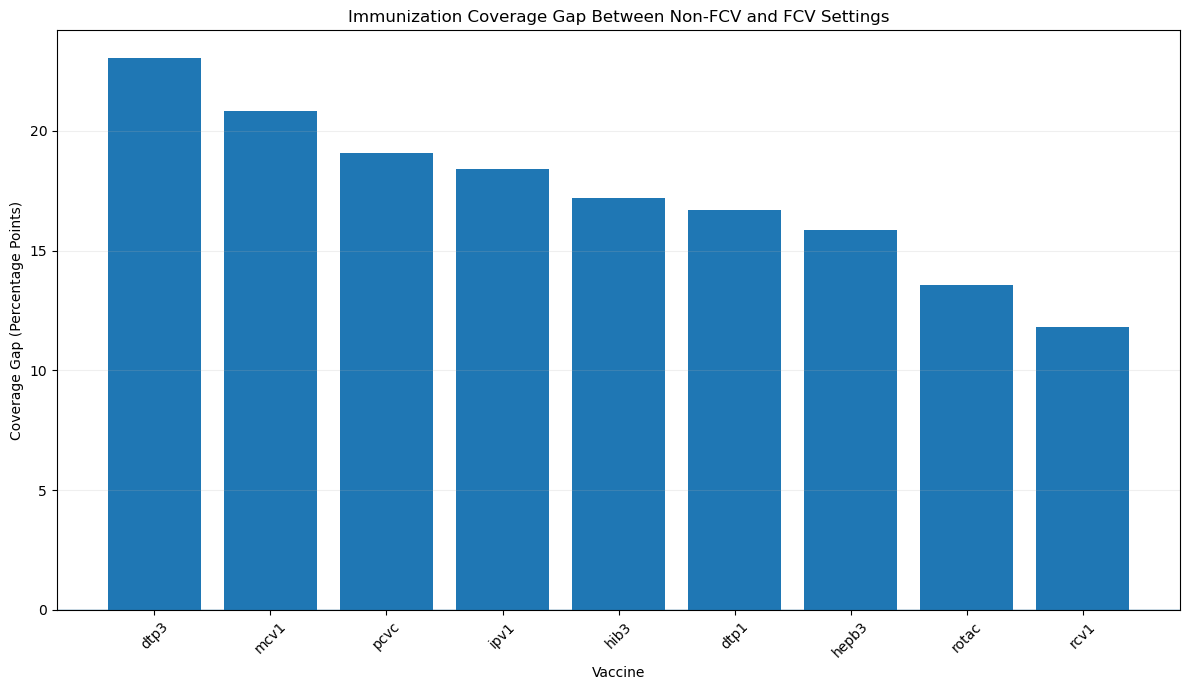

In [12]:
# Plot the FCV coverage gap across routine vaccines

plot_data = vaccine_comparison.reset_index()

plt.figure(figsize=(12, 7))

plt.bar(
    plot_data["vaccine"],
    plot_data["FCV_gap"]
)

plt.axhline(0, linewidth=1)

plt.title("Immunization Coverage Gap Between Non-FCV and FCV Settings")
plt.xlabel("Vaccine")
plt.ylabel("Coverage Gap (Percentage Points)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
# Identify recent country-level immunization patterns

recent_dtp3 = dtp3[
    dtp3["year"].eq(2025)
].copy()

recent_dtp3 = recent_dtp3.sort_values(
    "coverage",
    ascending=False
)

print("Countries with the highest DTP3 coverage in 2025:")
display(
    recent_dtp3[
        ["country", "iso3c", "FCV", "coverage"]
    ].head(15)
)

print("\nCountries with the lowest DTP3 coverage in 2025:")
display(
    recent_dtp3[
        ["country", "iso3c", "FCV", "coverage"]
    ].tail(15)
)

Countries with the highest DTP3 coverage in 2025:


,country,iso3c,FCV,coverage
8133,Bhutan,BTN,Non-FCV,99
7799,Brunei Darussalam,BRN,Non-FCV,99
2296,Antigua and Barbuda,ATG,Non-FCV,99
19392,Ghana,GHA,Non-FCV,99
12873,Cuba,CUB,Non-FCV,99
43074,Portugal,PRT,Non-FCV,99
43738,State of Palestine,PSE,FCV,99
47160,El Salvador,SLV,Non-FCV,99
55695,Saint Vincent and the Grenadines,VCT,Non-FCV,99
53580,Tuvalu,TUV,Non-FCV,99



Countries with the lowest DTP3 coverage in 2025:


,country,iso3c,FCV,coverage
32771,Madagascar,MDG,Non-FCV,64
37668,Nigeria,NGA,FCV,62
18563,Gabon,GAB,Non-FCV,62
134,Afghanistan,AFG,FCV,61
50422,Syrian Arab Republic,SYR,FCV,60
6773,Bolivia (Plurinational State of),BOL,Non-FCV,59
22685,Haiti,HTI,FCV,58
26508,Kazakhstan,KAZ,Non-FCV,54
29239,Lebanon,LBN,FCV,52
413,Angola,AGO,Non-FCV,52


In [14]:
# Identify priority FCV settings based on recent DTP3 coverage

fcv_2025 = recent_dtp3[
    recent_dtp3["FCV"].eq("FCV")
].copy()

priority_countries = fcv_2025.sort_values(
    "coverage",
    ascending=True
)

print("Lowest DTP3 coverage among FCV settings in 2025:")
display(
    priority_countries[
        ["country", "iso3c", "coverage"]
    ].head(20)
)

Lowest DTP3 coverage among FCV settings in 2025:


,country,iso3c,coverage
57257,Yemen,YEM,39
42150,Papua New Guinea,PNG,43
8733,Central African Republic,CAF,46
29239,Lebanon,LBN,52
22685,Haiti,HTI,58
50422,Syrian Arab Republic,SYR,60
134,Afghanistan,AFG,61
37668,Nigeria,NGA,62
35654,Mozambique,MOZ,70
45680,Sudan,SDN,71


In [15]:
# Measure DTP3 recovery from 2021 to 2025

recovery = dtp3[
    dtp3["year"].isin([2021, 2025])
].pivot_table(
    index=["iso3c", "country", "FCV"],
    columns="year",
    values="coverage"
).reset_index()

recovery = recovery.dropna(
    subset=[2021, 2025]
)

recovery["change_2021_2025"] = (
    recovery[2025] - recovery[2021]
)

print("Average DTP3 recovery from 2021 to 2025:")
display(
    recovery.groupby("FCV")["change_2021_2025"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

print("\nCountries with the largest DTP3 recovery:")
display(
    recovery.sort_values(
        "change_2021_2025",
        ascending=False
    ).head(15)
)

print("\nCountries with the largest decline after 2021:")
display(
    recovery.sort_values(
        "change_2021_2025",
        ascending=True
    ).head(15)
)

Average DTP3 recovery from 2021 to 2025:


,count,mean,median,std,min,max
FCV,,,,,,
FCV,24,6.46,8.5,10.89,-17.0,34.0
Non-FCV,171,0.62,0.0,6.56,-32.0,24.0



Countries with the largest DTP3 recovery:


year,iso3c,country,FCV,2021,2025,change_2021_2025
116,MMR,Myanmar,FCV,37.0,71.0,34.0
46,DJI,Djibouti,Non-FCV,59.0,83.0,24.0
23,BRA,Brazil,Non-FCV,68.0,86.0,18.0
99,LBY,Libya,FCV,73.0,90.0,17.0
70,GRD,Grenada,Non-FCV,77.0,93.0,16.0
98,LBR,Liberia,Non-FCV,67.0,83.0,16.0
182,UKR,Ukraine,FCV,78.0,94.0,16.0
77,IDN,Indonesia,Non-FCV,67.0,82.0,15.0
189,VUT,Vanuatu,Non-FCV,62.0,77.0,15.0
119,MOZ,Mozambique,FCV,56.0,70.0,14.0



Countries with the largest decline after 2021:


year,iso3c,country,FCV,2021,2025,change_2021_2025
132,NRU,Nauru,Non-FCV,98.0,66.0,-32.0
192,ZAF,South Africa,Non-FCV,86.0,65.0,-21.0
147,ROU,Romania,Non-FCV,86.0,66.0,-20.0
191,YEM,Yemen,FCV,56.0,39.0,-17.0
97,LBN,Lebanon,FCV,67.0,52.0,-15.0
61,GAB,Gabon,Non-FCV,75.0,62.0,-13.0
151,SDN,Sudan,FCV,84.0,71.0,-13.0
124,NAM,Namibia,Non-FCV,94.0,82.0,-12.0
22,BOL,Bolivia (Plurinational State of),Non-FCV,70.0,59.0,-11.0
161,STP,Sao Tome and Principe,Non-FCV,97.0,87.0,-10.0


In [17]:
# Prepare the HPV dataset and examine its completeness

hpv["year"] = pd.to_numeric(
    hpv["year"],
    errors="coerce"
)

hpv["coverage"] = pd.to_numeric(
    hpv["coverage"],
    errors="coerce"
)

hpv["iso3c"] = (
    hpv["iso3c"]
    .astype(str)
    .str.upper()
    .str.strip()
)

hpv["vaccine"] = (
    hpv["vaccine"]
    .astype(str)
    .str.strip()
)

hpv["world_bank_fcv"] = (
    hpv["world_bank_fcv"]
    .astype(str)
    .str.lower()
    .str.strip()
)

# Create FCV classification using pandas mapping.
# This safely handles missing classifications.
fcv_mapping = {
    "wb_fcv": "FCV",
    "non_wb_fcv": "Non-FCV"
}

hpv["FCV"] = (
    hpv["world_bank_fcv"]
    .map(fcv_mapping)
    .astype("string")
)

print("HPV dataset shape:", hpv.shape)

print("\nHPV vaccine indicators:")
print(
    hpv["vaccine"]
    .value_counts(dropna=False)
)

print("\nFCV classification:")
print(
    hpv["FCV"]
    .value_counts(dropna=False)
)

print("\nMissing values:")
display(
    hpv[
        [
            "iso3c",
            "year",
            "vaccine",
            "coverage",
            "FCV"
        ]
    ]
    .isna()
    .sum()
)

print("\nCoverage summary:")
print(
    hpv["coverage"].describe()
)

HPV dataset shape: (3426, 18)

HPV vaccine indicators:
vaccine
HPV    3426
Name: count, dtype: int64

FCV classification:
FCV
Non-FCV    3354
FCV          72
Name: count, dtype: Int64

Missing values:


iso3c       0
year        0
vaccine     0
coverage    0
FCV         0
dtype: int64


Coverage summary:
count    3426.000000
mean       54.829247
std        27.951340
min         0.000000
25%        34.000000
50%        59.000000
75%        77.000000
max        99.000000
Name: coverage, dtype: float64


In [18]:
# Compare HPV coverage between FCV and non-FCV settings

hpv_clean = hpv.dropna(
    subset=["coverage", "FCV", "year"]
).copy()

hpv_summary = (
    hpv_clean
    .groupby(["vaccine", "FCV"])["coverage"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

hpv_comparison = (
    hpv_summary
    .pivot(index="vaccine", columns="FCV", values="mean")
)

hpv_comparison["FCV_gap"] = (
    hpv_comparison["Non-FCV"] -
    hpv_comparison["FCV"]
)

print("HPV coverage comparison:")
display(hpv_comparison.round(2))

HPV coverage comparison:


FCV,FCV,Non-FCV,FCV_gap
vaccine,,,
HPV,51.46,54.9,3.44


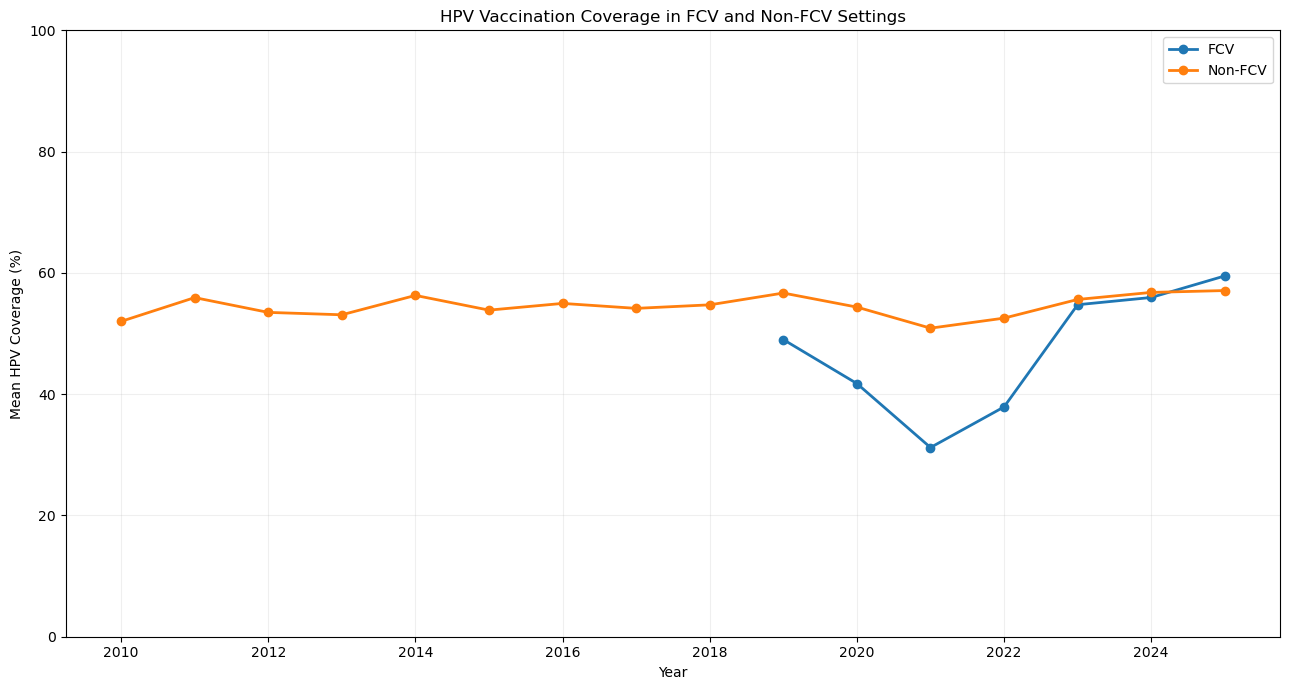

In [19]:
# Plot HPV coverage trends by FCV status

hpv_annual = (
    hpv_clean
    .groupby(["year", "FCV"])["coverage"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(13, 7))

for group in ["FCV", "Non-FCV"]:
    subset = hpv_annual[
        hpv_annual["FCV"].eq(group)
    ].sort_values("year")

    plt.plot(
        subset["year"],
        subset["coverage"],
        marker="o",
        linewidth=2,
        label=group
    )

plt.title("HPV Vaccination Coverage in FCV and Non-FCV Settings")
plt.xlabel("Year")
plt.ylabel("Mean HPV Coverage (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [20]:
# Examine the survey evidence underlying the immunization estimates

survey["cohortYear"] = pd.to_numeric(
    survey["cohortYear"],
    errors="coerce"
)

survey["coverage"] = pd.to_numeric(
    survey["coverage"],
    errors="coerce"
)

survey["denominator"] = pd.to_numeric(
    survey["denominator"],
    errors="coerce"
)

survey["ISO3"] = (
    survey["ISO3"]
    .astype(str)
    .str.upper()
    .str.strip()
)

print("Survey observations:", len(survey))

print("\nMissing values:")
display(
    survey.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

print("\nEvidence types:")
display(
    survey["evidence"]
    .value_counts(dropna=False)
)

print("\nValidity categories:")
display(
    survey["validity"]
    .value_counts(dropna=False)
)

Survey observations: 51316

Missing values:


,missing
cardsSeen,16608
denominator,3515
surveyNameEnglish,2290
ageVaccination,1448
collectEnd,106
collectBegin,106
coverage,85
ageInterview,5
validity,4
evidence,4



Evidence types:


evidence
Record or Recall            15705
Record                      12808
Record or Recall<12m        10809
Recall                      10120
NOT USED                      654
Record<12m                    523
Record or Recall<18m          255
Record2                       237
Record1                        97
Record or Recall<24m           27
Recall<12m                     26
Record or Scar                 21
Scar                           18
Record or Recall<15m           10
NaN                             4
Record or Scar<12m              1
Record or Recall or Scar        1
Name: count, dtype: int64


Validity categories:


validity
CRUDE    51312
NaN          4
Name: count, dtype: int64

In [22]:
# Compare survey evidence between FCV and non-FCV countries
survey_fcv = survey.merge(
    wuenic[
        ["iso3c", "world_bank_fcv"]
    ].drop_duplicates("iso3c"),
    left_on="ISO3",
    right_on="iso3c",
    how="left"
)
survey_fcv["FCV"] = survey_fcv["world_bank_fcv"].map({
    "wb_fcv": "FCV",
    "non_wb_fcv": "Non-FCV"
})
evidence_summary = (
    survey_fcv
    .dropna(subset=["FCV"])
    .groupby(["FCV", "evidence"])
    .size()
    .reset_index(name="observations")
)
print("Survey evidence types by FCV status:")
display(evidence_summary)

Survey evidence types by FCV status:


,FCV,evidence,observations
0,FCV,NOT USED,125
1,FCV,Recall,1886
2,FCV,Recall<12m,18
3,FCV,Record,2276
4,FCV,Record or Recall,2846
5,FCV,Record or Recall<12m,1873
6,FCV,Record or Recall<18m,2
7,FCV,Record or Recall<24m,5
8,FCV,Record or Scar,3
9,FCV,Record1,43


In [23]:
# Generate the main numerical findings for the research report

overall = dtp3.groupby("FCV")["coverage"].agg(
    observations="count",
    mean="mean",
    median="median",
    standard_deviation="std"
).round(2)

gap = (
    overall.loc["Non-FCV", "mean"] -
    overall.loc["FCV", "mean"]
)

print("MAIN FINDINGS")
print()

print("1. Overall DTP3 coverage")
display(overall)

print(
    f"2. Overall DTP3 inequality gap: "
    f"{gap:.2f} percentage points"
)

print()

print("3. DTP3 coverage by selected years")

selected_years = [2015, 2019, 2020, 2021, 2022, 2025]

selected = gap_table.loc[
    gap_table.index.isin(selected_years)
].round(2)

display(selected)

print()

print("4. Largest observed FCV inequality gaps")
display(
    gap_table
    .sort_values("FCV_gap", ascending=False)
    .head(10)
    .round(2)
)

print()

print("5. DTP3 recovery between 2021 and 2025")
display(
    recovery.groupby("FCV")["change_2021_2025"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print()

print("6. Statistical comparison")
print("Welch t-test p-value:", welch_test.pvalue)
print("Cohen's d:", round(cohens_d, 3))

MAIN FINDINGS

1. Overall DTP3 coverage


,observations,mean,median,standard_deviation
FCV,,,,
FCV,1028,60.24,63.0,26.46
Non-FCV,7312,83.29,91.0,19.13


2. Overall DTP3 inequality gap: 23.05 percentage points

3. DTP3 coverage by selected years


FCV,FCV,Non-FCV,FCV_gap
year,,,
2015,69.62,90.70,21.07
2019,73.04,90.76,17.72
2020,70.58,88.27,17.69
2021,66.62,87.82,21.19
2022,69.92,88.46,18.54
2025,73.08,88.44,15.36



4. Largest observed FCV inequality gaps


FCV,FCV,Non-FCV,FCV_gap
year,,,
1983,19.78,56.75,36.97
1982,19.17,55.48,36.31
1981,17.11,53.08,35.96
1985,27.38,62.10,34.72
1984,23.89,58.60,34.71
1987,36.71,71.20,34.49
1986,33.86,67.62,33.77
1980,18.25,51.32,33.07
1988,45.57,74.25,28.68



5. DTP3 recovery between 2021 and 2025


,count,mean,median,std
FCV,,,,
FCV,24,6.46,8.5,10.89
Non-FCV,171,0.62,0.0,6.56



6. Statistical comparison
Welch t-test p-value: 3.409388101417179e-125
Cohen's d: 1.142
